# State-Compensated Medicine Allocation Analysis (year 2026) (pub. Sipoteni, june 2026)

## Executive Summary
This project evaluates a dataset containing 1,878 records of state-compensated medical prescriptions. The goal is to analyze financial allocations across different patient demographics and disease groups to determine how healthcare funding is distributed.

### Strategic Goals:
1. Ensure strict data compliance via comprehensive **Data Anonymization** (removing PII such as names and IDNPs).
2. Evaluate patient demographics using distribution metrics.
3. Map financial density curves to identify high-impact healthcare expenditures.

In [73]:
import os
import pandas as pd

# Define file names
raw_file = 'set_data.csv'
clean_file = 'set_data_clean.csv'

# Check if the clean file already exists (e.g., when hosted on GitHub)
if os.path.exists(clean_file):
    print(f"Clean dataset found! Loading compliant data directly...")
    df = pd.read_csv(clean_file)
    
elif os.path.exists(raw_file):
    print(f"Raw dataset found. Executing compliance pipeline...")
    raw_df = pd.read_csv(raw_file)
    
    # Run anonymization
    df = raw_df.drop(columns=['patientFirstName', 'patientLastName'])
    
    patient_map = {idnp: f"Patient_{idx+1}" for idx, idnp in enumerate(df['patientIdentifier'].unique())}
    df['patient_id'] = df['patientIdentifier'].map(patient_map)
    df = df.drop(columns=['patientIdentifier'])
    
    df['pharmacist_name'] = df['pharmacistIDNP'].apply(
        lambda x: " ".join(str(x).split()[1:]) if len(str(x).split()) > 1 else str(x)
    )
    df = df.drop(columns=['pharmacistIDNP'])
    
    # Save the clean version
    df.to_csv(clean_file, index=False)
    print(f"Sanitized file created successfully.")
    
else:
    raise FileNotFoundError("Neither the raw dataset nor the clean dataset could be found in this directory.")

print(f"Active rows ready for visualization: {len(df)}")

Clean dataset found! Loading compliant data directly...
Active rows ready for visualization: 1878


## Environment Configuration & UI Styling
We apply the `ggplot` plotting schema to optimize the visualizations with clean grid structures and standard contrast properties.

In [74]:
%matplotlib inline

# Initialize plotting engine styling parameters
plt.style.use('ggplot')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f0f0f0'

print("Matplotlib style sheets loaded successfully.")

Matplotlib style sheets loaded successfully.


## 1. Demographic Analysis: Patient Age Distribution
Understanding the core demographic profile utilizing public health resources allows for accurate capacity planning. We construct a continuous distribution histogram to locate the peak consumer bracket.

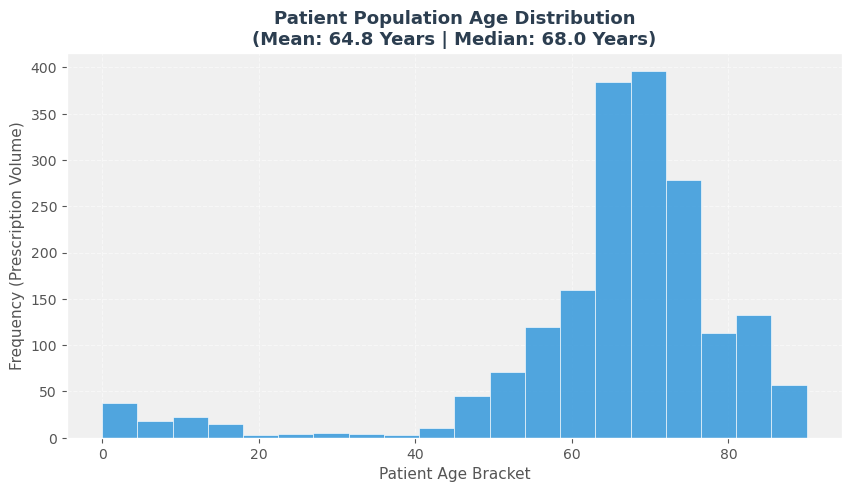

In [75]:
plt.figure(figsize=(10, 5))

# Generate structural histogram configuration
plt.hist(df['age'], bins=20, color='#3498db', edgecolor='white', alpha=0.85)

# Extract core descriptive metrics
mean_age = df['age'].mean()
median_age = df['age'].median()

# Title dynamic string configuration via variables
plt.title(f"Patient Population Age Distribution\n(Mean: {mean_age:.1f} Years | Median: {median_age:.1f} Years)", fontsize=13, weight='bold', color='#2c3e50')
plt.xlabel("Patient Age Bracket", fontsize=11)
plt.ylabel("Frequency (Prescription Volume)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 2. Resource Allocation: Top Funding Pools by Diagnostic Groups
By aggregating the total monetary payout (`compensatedAmount`) across distinct diagnostic subcategories, we highlight which pathologies command the highest financial footprint within the system.

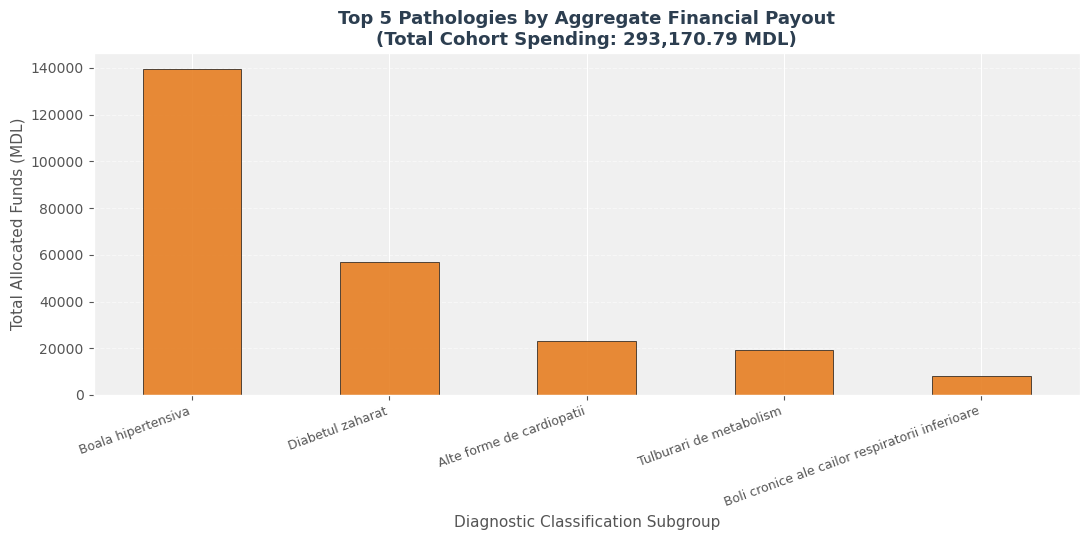

In [76]:
# Aggregate data frame matrices via group splits and sort descending
funding_by_diagnosis = df.groupby('diagnosticSubGroup')['compensatedAmount'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(11, 5.5))
funding_by_diagnosis.plot(kind='bar', color='#e67e22', edgecolor='black', alpha=0.9)

total_allocation = df['compensatedAmount'].sum()

plt.title(f"Top 5 Pathologies by Aggregate Financial Payout\n(Total Cohort Spending: {total_allocation:,.2f} MDL)", fontsize=13, weight='bold', color='#2c3e50')
plt.ylabel("Total Allocated Funds (MDL)", fontsize=11)
plt.xlabel("Diagnostic Classification Subgroup", fontsize=11)
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Financial Density Profiles: Age vs. Compensation Dynamics
To isolate trends where specific age brackets pull disproportionate amounts of higher-value medicine funding, we apply a scatter plot. Incorporating transparency mapping (`alpha=0.4`) natively surfaces localized overplotting clusters without distorting outlier values.

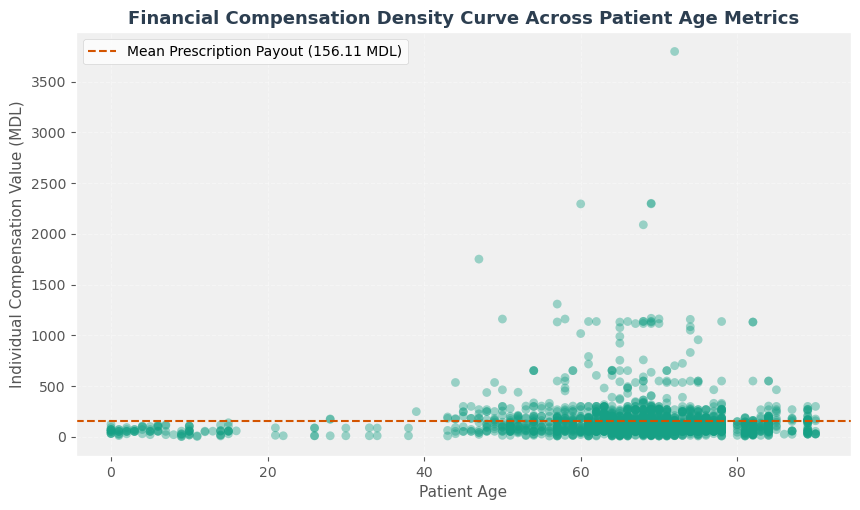

In [77]:
plt.figure(figsize=(10, 5.5))

# Scatter mapping vector metrics
plt.scatter(
    df['age'], 
    df['compensatedAmount'], 
    color='#16a085', 
    alpha=0.4, 
    s=40, 
    edgecolors='none'
)

# Reference benchmark implementation
global_mean = df['compensatedAmount'].mean()
plt.axhline(global_mean, color='#d35400', linestyle='--', linewidth=1.5, label=f"Mean Prescription Payout ({global_mean:.2f} MDL)")

plt.title("Financial Compensation Density Curve Across Patient Age Metrics", fontsize=13, weight='bold', color='#2c3e50')
plt.xlabel("Patient Age", fontsize=11)
plt.ylabel("Individual Compensation Value (MDL)", fontsize=11)
plt.legend(loc="upper left", facecolor='white', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()